# Notebook 2: Modellering

## 2.1 Ladda rent data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Data/clean_heart_disease.csv")
print(df.shape)
df.head()

(918, 21)


,Ålder,Viloblodtryck,Kolesterol,FastandeBlodsocker,MaxHjärtfrekvens,EKG_Sänkning,Hjärtsjukdom,Kön_F,Kön_M,Bröstsmärta_AnnanBröstsmärta,...,Bröstsmärta_KlassiskHjärtsmärta,Bröstsmärta_OtypiskHjärtsmärta,ViloEKG_Avvikelse,ViloEKG_LVH,ViloEKG_Normal,Ansträngningssmärta_Ja,Ansträngningssmärta_Nej,EKG_Lutning_Flat,EKG_Lutning_Nedåt,EKG_Lutning_Uppåt
0,40,140,289,0,172,0.0,0,0,1,0,...,0,1,0,0,1,0,1,0,0,1
1,49,160,180,0,156,1.0,1,1,0,1,...,0,0,0,0,1,0,1,1,0,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,1,0,0,...,0,0,0,0,1,1,0,1,0,0
4,54,150,195,0,122,0.0,0,0,1,1,...,0,0,0,0,1,0,1,0,0,1


## 2.2 Skalning & train/test-split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separerar features (X) från målvariabeln (y)
X = df.drop(columns=["Hjärtsjukdom"])
y = df["Hjärtsjukdom"]

# Delar upp i 80% träning och 20% test
# stratify=y säkerställer att andelen sjuka/friska är samma i båda delar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardiserar så att alla variabler har medel=0 och std=1
# Viktigt för KNN och Logistisk Regression som är känsliga för skalskillnader
# fit_transform på träning, bara transform på test — annars läcker testdata in i träningen
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Träning: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Träning: (734, 20), Test: (184, 20)


## 2.3 Logistisk Regression

=== Logistisk Regression ===
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.933


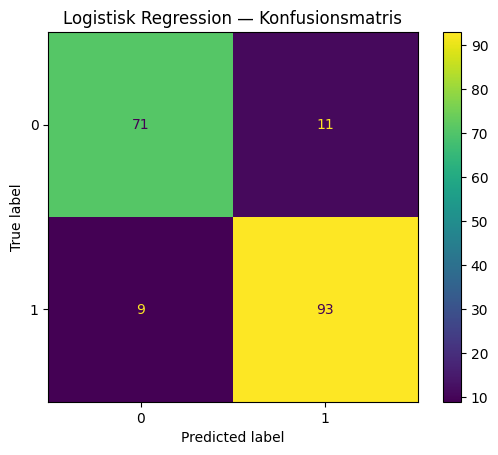

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Tränar logistisk regression — en enkel men ofta stark baslinjemodell
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistisk Regression ===")
# classification_report visar precision, recall och F1 per klass
# Recall är extra viktigt här — vi vill inte missa sjuka patienter
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.3f}")

# Konfusionsmatrisen visar hur många rätt och fel per klass
# Falskt negativa (sjuk klassad som frisk) är det farligaste felet
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot()
plt.title("Logistisk Regression — Konfusionsmatris")
plt.show()

## 2.4 KNN

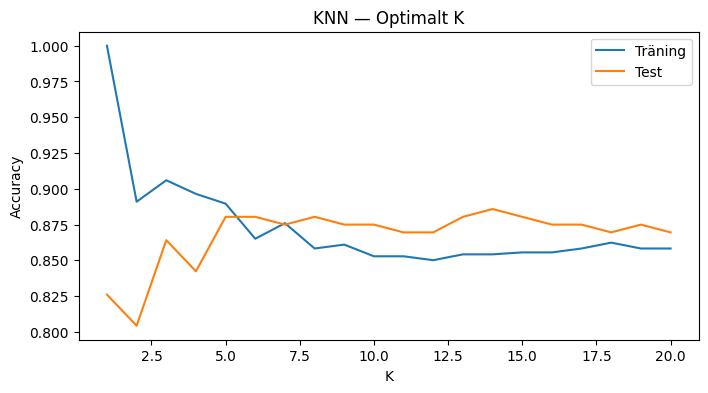

Bästa K: 14

=== KNN ===
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.922


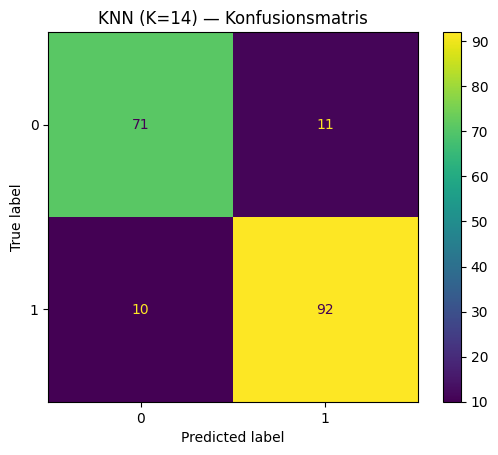

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# Testar K från 1 till 20 för att hitta det värde som ger bäst testaccuracy
# Lågt K = modellen memorerar träningsdata (overfitting)
# Högt K = modellen blir för generell (underfitting)
train_acc, test_acc = [], []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4))
plt.plot(k_range, train_acc, label="Träning")
plt.plot(k_range, test_acc, label="Test")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN — Optimalt K")
plt.legend()
plt.show()

# Väljer det K som gav högst accuracy på testdata
bästa_k = k_range[np.argmax(test_acc)]
print(f"Bästa K: {bästa_k}")

# Tränar om modellen med det optimala K
knn = KNeighborsClassifier(n_neighbors=bästa_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("\n=== KNN ===")
print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC: {roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]):.3f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot()
plt.title(f"KNN (K={bästa_k}) — Konfusionsmatris")
plt.show()

## 2.5 Testa LR och KNN på komprimerad data (PCA/UMAP)

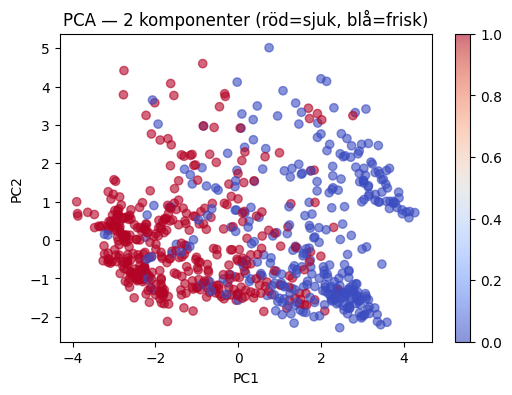

PCA + LR  Accuracy: 0.902
PCA + KNN Accuracy: 0.853


C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


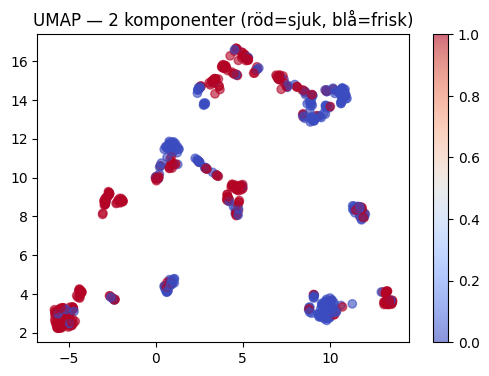

UMAP + LR  Accuracy: 0.772
UMAP + KNN Accuracy: 0.864


In [11]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import umap

# --- PCA ---
# Komprimerar de 20 variablerna till 2 dimensioner för att kunna visualisera datan
# Om klussarna syns tydligt separerade är det ett gott tecken för modellerna
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
plt.colorbar(scatter)
plt.title("PCA — 2 komponenter (röd=sjuk, blå=frisk)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Tränar LR och KNN på PCA-komprimerad data med 5 komponenter
# Pipeline säkerställer att PCA och modellen behandlas som ett steg — ingen data leakage
pipe_pca_lr = Pipeline([("pca", PCA(n_components=5)), ("lr", LogisticRegression(max_iter=1000))])
pipe_pca_lr.fit(X_train_scaled, y_train)
print(f"PCA + LR  Accuracy: {pipe_pca_lr.score(X_test_scaled, y_test):.3f}")

pipe_pca_knn = Pipeline([("pca", PCA(n_components=5)), ("knn", KNeighborsClassifier(n_neighbors=bästa_k))])
pipe_pca_knn.fit(X_train_scaled, y_train)
print(f"PCA + KNN Accuracy: {pipe_pca_knn.score(X_test_scaled, y_test):.3f}")

# --- UMAP ---
# UMAP är en icke-linjär metod som ofta hittar tydligare kluster än PCA
# random_state sätts för att resultatet ska bli reproducerbart
reducer = umap.UMAP(n_components=2, random_state=42)
X_train_umap = reducer.fit_transform(X_train_scaled)
X_test_umap = reducer.transform(X_test_scaled)

plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
plt.colorbar(scatter)
plt.title("UMAP — 2 komponenter (röd=sjuk, blå=frisk)")
plt.show()

# Tränar LR och KNN direkt på UMAP-koordinaterna (2 dimensioner)
lr_umap = LogisticRegression(max_iter=1000)
lr_umap.fit(X_train_umap, y_train)
print(f"UMAP + LR  Accuracy: {lr_umap.score(X_test_umap, y_test):.3f}")

knn_umap = KNeighborsClassifier(n_neighbors=bästa_k)
knn_umap.fit(X_train_umap, y_train)
print(f"UMAP + KNN Accuracy: {knn_umap.score(X_test_umap, y_test):.3f}")

## 2.6 Spara resultat

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Hjälpfunktion som räknar ut alla mått för en modell på en gång
def metrics(name, y_true, y_pred, model=None, X=None):
    return {
        "Modell": name,
        "Accuracy": round((y_true == y_pred).mean(), 3),
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall": round(recall_score(y_true, y_pred), 3),
        "F1": round(f1_score(y_true, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_true, model.predict_proba(X)[:,1]), 3) if model else "-"
    }

# Samlar alla modellers resultat i en tabell för enkel jämförelse i notebook 3
resultat = pd.DataFrame([
    metrics("Logistisk Regression", y_test, y_pred_lr, lr, X_test_scaled),
    metrics("KNN", y_test, y_pred_knn, knn, X_test_scaled),
    metrics("PCA + LR", y_test, pipe_pca_lr.predict(X_test_scaled), pipe_pca_lr, X_test_scaled),
    metrics("PCA + KNN", y_test, pipe_pca_knn.predict(X_test_scaled), pipe_pca_knn, X_test_scaled),
    metrics("UMAP + LR", y_test, lr_umap.predict(X_test_umap), lr_umap, X_test_umap),
    metrics("UMAP + KNN", y_test, knn_umap.predict(X_test_umap), knn_umap, X_test_umap),
])

# Sparar till CSV så att notebook 3 kan läsa in det direkt
resultat.to_csv("Data/modellresultat.csv", index=False)
print(resultat.to_string(index=False))

              Modell  Accuracy  Precision  Recall    F1  ROC-AUC
Logistisk Regression     0.891      0.894   0.912 0.903    0.933
                 KNN     0.886      0.893   0.902 0.898    0.922
            PCA + LR     0.902      0.920   0.902 0.911    0.931
           PCA + KNN     0.853      0.879   0.853 0.866    0.908
           UMAP + LR     0.772      0.778   0.824 0.800    0.758
          UMAP + KNN     0.864      0.889   0.863 0.876    0.920
